In [54]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [42]:
df_users = pd.read_csv('acc-data/ACC-usagers-2018.csv')
df_vroom = pd.read_csv('acc-data/ACC-vehicules-2018.csv')
df_acc = pd.read_csv("acc-data/ACC-caracteristiques-2018.csv")

In [43]:
merged = df_users.merge(df_vroom,"inner","Num_Acc")
merged = merged.merge(df_acc,'inner',on="Num_Acc")
merged

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,...,agg,int,atm,col,com,adr,gps,lat,long,dep
0,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
1,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
2,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
3,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
4,201800000002,1.0,1,1,1,0.0,11.0,0.0,0.0,0.0,...,2,7,7.0,7.0,11,Place du général de Gaul,M,5052936.0,293151.0,590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248401,201800057782,1.0,1,4,1,9.0,21.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,cavani-Kavani sud ( rue,Y,1278622.0,4522036.0,976
248402,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,m'tsapere-Nationale 2 (r,Y,1278943.0,4522408.0,976
248403,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,m'tsapere-Nationale 2 (r,Y,1278943.0,4522408.0,976
248404,201800057783,1.0,1,4,2,9.0,11.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,m'tsapere-Nationale 2 (r,Y,1278943.0,4522408.0,976


In [44]:
df_Boom = merged[["Num_Acc","grav","trajet","manv","dep"]]
df_Boom

,Num_Acc,grav,trajet,manv,dep
0,201800000001,3,0.0,1.0,590
1,201800000001,3,0.0,15.0,590
2,201800000001,1,5.0,1.0,590
3,201800000001,1,5.0,15.0,590
4,201800000002,1,0.0,1.0,590
...,...,...,...,...,...
248401,201800057782,4,9.0,0.0,976
248402,201800057783,4,9.0,0.0,976
248403,201800057783,4,9.0,0.0,976
248404,201800057783,4,9.0,0.0,976


In [45]:
Lyon_Boom = df_Boom[df_Boom["dep"] == 690]

Paris_Boom = df_Boom[df_Boom["dep"] == 750]

In [46]:
lyon_by_manu = Lyon_Boom.groupby("manv")["Num_Acc"].size()
lyon_by_manu = lyon_by_manu.reset_index()

paris_by_manu = Paris_Boom.groupby("manv")["Num_Acc"].size()
paris_by_manu = paris_by_manu.reset_index()

In [47]:
severe_Lyon = Lyon_Boom[ (Lyon_Boom["grav"] == 2) | (Lyon_Boom["grav"] == 3)]
severe_lyon_by = severe_Lyon.groupby("manv")["Num_Acc"].size()
severe_lyon_by = severe_lyon_by.reset_index()

severe_Paris = Paris_Boom[ (Paris_Boom["grav"] == 2) | (Paris_Boom["grav"] == 3)]
severe_paris_by = severe_Paris.groupby("manv")["Num_Acc"].size()
severe_paris_by = severe_paris_by.reset_index()

In [48]:
final_lyon = lyon_by_manu.merge(severe_lyon_by,"left",on="manv")

final_paris = paris_by_manu.merge(severe_paris_by,"left",on="manv")

In [49]:
final_lyon["per"] = (final_lyon["Num_Acc_y"] / final_lyon["Num_Acc_x"]) * 100

final_paris["per"] = (final_paris["Num_Acc_y"] / final_paris["Num_Acc_x"]) * 100

(0.0, 40.0)

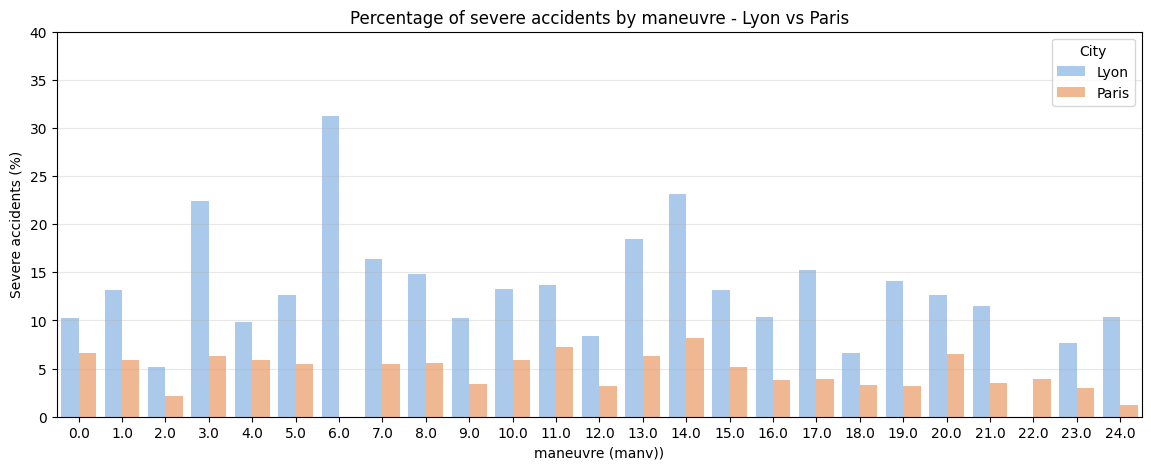

In [53]:
final_lyon["city"] = "Lyon"
final_paris["city"] = "Paris"

combined = pd.concat([final_lyon, final_paris], ignore_index=True)

plt.figure(figsize=(14, 5))
sns.barplot(data=combined, x="manv", y="per", hue="city", palette="pastel")
plt.xlabel("maneuvre (manv))")
plt.ylabel("Severe accidents (%)")
plt.title("Percentage of severe accidents by maneuvre - Lyon vs Paris")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="City")
plt.ylim(0,40)